# Meal Detection Method Comparison: Paper vs IPI

This notebook compares two meal detection methods available in the codebase:

1. **Paper Method**: Fixed duration approach - a meal starts with a pellet and includes all subsequent pellets within 60 seconds of the **first** pellet.

2. **IPI (Interpellet Interval) Method**: Groups pellets based on time between **consecutive** pellets. A new meal starts when the gap between consecutive pellets exceeds 60 seconds.

## Key Differences

| Aspect | Paper Method | IPI Method |
|--------|-------------|------------|
| Grouping Logic | All pellets within threshold of meal start | Consecutive pellets within threshold of each other |
| Meal Duration | Max ~60s from first pellet | Can extend indefinitely if pellets keep coming |
| Chain Behavior | Breaks after 60s regardless of ongoing eating | Continues as long as gaps < 60s |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
from pathlib import Path
import sys

# Add scripts to path
sys.path.insert(0, str(Path.cwd()))

from scripts.preprocessing import load_session_csv, build_session_catalog
from scripts.meals import find_meals_paper, _find_meals_paper_original, _find_meals_ipi

# Configuration
SAMPLE_ROOT = Path('sample_data')
GROUP_MAP = Path('group_map.json')

plt.rcParams['figure.figsize'] = (16, 8)
plt.rcParams['font.size'] = 11


Using device: mps


## 1. Load Sample Sessions


In [2]:
# Build session catalog
session_store, groupings = build_session_catalog(SAMPLE_ROOT, GROUP_MAP)

# Get a few sample sessions for comparison
sample_sessions = []
for group_name, session_types in groupings.items():
    for session_key in session_types.get('FR1', [])[:2]:  # Take 2 FR1 sessions per group
        sample_sessions.append(session_store[session_key.session_id])
    for session_key in session_types.get('REV', [])[:2]:  # Take 2 REV sessions per group
        sample_sessions.append(session_store[session_key.session_id])

print(f"Loaded {len(sample_sessions)} sample sessions for comparison")
for s in sample_sessions[:5]:
    print(f"  - {s.key.session_id} ({s.key.session_type}, Group: {s.key.group})")


/Users/yaomingyang/Desktop/FT Lab/FEDUPP/scripts/preprocessing.py:163: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Time"] = pd.to_datetime(df["Time"], errors="coerce")
/Users/yaomingyang/Desktop/FT Lab/FEDUPP/scripts/preprocessing.py:163: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Time"] = pd.to_datetime(df["Time"], errors="coerce")
/Users/yaomingyang/Desktop/FT Lab/FEDUPP/scripts/preprocessing.py:163: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Time"] = pd.to_datetime(df["Time"], errors="coerce")
/Users/yaomingyang/Desktop/FT Lab/FEDUPP/scripts/preproces

Loaded 12 sample sessions for comparison
  - M1_fr1 (FR1, Group: cask)
  - M2_fr1 (FR1, Group: cask)
  - M8_reversal (REV, Group: cask)
  - M9_reversal (REV, Group: cask)
  - M33_fr1 (FR1, Group: ctrl)


/Users/yaomingyang/Desktop/FT Lab/FEDUPP/scripts/preprocessing.py:163: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Time"] = pd.to_datetime(df["Time"], errors="coerce")


## 2. Compare Meal Detection Methods


In [4]:
def compare_meal_methods(data: pd.DataFrame, time_threshold: int = 60, pellet_threshold: int = 2):
    """
    Compare paper vs IPI meal detection on the same data.
    
    Returns:
        dict with 'paper' and 'ipi' results, each containing meals and meal_acc.
    """
    paper_meals, paper_acc = find_meals_paper(
        data, 
        time_threshold=time_threshold, 
        pellet_threshold=pellet_threshold,
        accuracy_threshold=-1.0,  # Include all meals
        method='paper'
    )
    
    ipi_meals, ipi_acc = find_meals_paper(
        data,
        time_threshold=time_threshold,
        pellet_threshold=pellet_threshold,
        accuracy_threshold=-1.0,  # Include all meals
        method='ipi'
    )
    
    return {
        'paper': {'meals': paper_meals, 'acc': paper_acc},
        'ipi': {'meals': ipi_meals, 'acc': ipi_acc}
    }


In [5]:
def get_meal_stats(meals, data):
    """
    Calculate statistics for a list of meals.
    """
    if not meals:
        return {'count': 0, 'avg_duration': 0, 'avg_pellets': 0, 'total_pellets': 0, 'max_duration': 0}
    
    durations = []
    pellet_counts = []
    
    for start, end in meals:
        duration = (end - start).total_seconds()
        durations.append(duration)
        
        # Count pellets in this meal
        meal_data = data[(data['Time'] >= start) & (data['Time'] <= end)]
        pellet_count = len(meal_data[meal_data['Event'] == 'Pellet'])
        pellet_counts.append(pellet_count)
    
    return {
        'count': len(meals),
        'avg_duration': np.mean(durations),
        'max_duration': np.max(durations),
        'avg_pellets': np.mean(pellet_counts),
        'total_pellets': sum(pellet_counts)
    }


In [6]:
# Compare methods across all sample sessions
comparison_results = []

for session in sample_sessions:
    data = session.raw.copy()
    result = compare_meal_methods(data)
    
    paper_stats = get_meal_stats(result['paper']['meals'], data)
    ipi_stats = get_meal_stats(result['ipi']['meals'], data)
    
    comparison_results.append({
        'session_id': session.key.session_id,
        'session_type': session.key.session_type,
        'group': session.key.group,
        'paper_meal_count': paper_stats['count'],
        'ipi_meal_count': ipi_stats['count'],
        'paper_avg_duration': paper_stats['avg_duration'],
        'ipi_avg_duration': ipi_stats['avg_duration'],
        'paper_max_duration': paper_stats.get('max_duration', 0),
        'ipi_max_duration': ipi_stats.get('max_duration', 0),
        'paper_avg_pellets': paper_stats['avg_pellets'],
        'ipi_avg_pellets': ipi_stats['avg_pellets'],
        'paper_total_pellets': paper_stats['total_pellets'],
        'ipi_total_pellets': ipi_stats['total_pellets'],
    })

comparison_df = pd.DataFrame(comparison_results)
comparison_df


,session_id,session_type,group,paper_meal_count,ipi_meal_count,paper_avg_duration,ipi_avg_duration,paper_max_duration,ipi_max_duration,paper_avg_pellets,ipi_avg_pellets,paper_total_pellets,ipi_total_pellets
0,M1_fr1,FR1,cask,51,36,39.588235,80.194444,60.0,389.0,2.294118,3.500000,117,126
1,M2_fr1,FR1,cask,56,41,37.839286,70.585366,60.0,236.0,2.232143,3.243902,125,133
2,M8_reversal,REV,cask,186,106,42.376344,108.283019,60.0,358.0,2.623656,5.009434,488,531
3,M9_reversal,REV,cask,183,101,42.174863,106.841584,60.0,266.0,2.693989,5.188119,493,524
4,M33_fr1,FR1,ctrl,64,43,41.375000,82.604651,60.0,270.0,2.453125,3.883721,157,167
5,M34_fr1,FR1,ctrl,46,23,42.673913,120.478261,60.0,268.0,2.673913,5.695652,123,131
6,M40_reversal,REV,ctrl,152,111,40.065789,72.531532,60.0,353.0,2.690789,3.945946,409,438
7,M41_reversal,REV,ctrl,160,100,40.618750,86.850000,60.0,383.0,2.650000,4.480000,424,448
8,M68_fr1,FR1,female,4,4,48.750000,48.750000,59.0,59.0,2.000000,2.000000,8,8
9,M69_fr1,FR1,female,65,46,41.138462,88.326087,59.0,202.0,2.230769,3.565217,145,164


## 3. Summary Statistics Comparison


In [7]:
# Aggregate statistics
print("=" * 60)
print("MEAL DETECTION METHOD COMPARISON SUMMARY")
print("=" * 60)

print("\n--- Meal Counts ---")
print(f"Paper Method - Mean: {comparison_df['paper_meal_count'].mean():.1f}, Total: {comparison_df['paper_meal_count'].sum()}")
print(f"IPI Method   - Mean: {comparison_df['ipi_meal_count'].mean():.1f}, Total: {comparison_df['ipi_meal_count'].sum()}")

print("\n--- Average Meal Duration (seconds) ---")
print(f"Paper Method - Mean: {comparison_df['paper_avg_duration'].mean():.1f}s")
print(f"IPI Method   - Mean: {comparison_df['ipi_avg_duration'].mean():.1f}s")

print("\n--- Maximum Meal Duration (seconds) ---")
print(f"Paper Method - Mean Max: {comparison_df['paper_max_duration'].mean():.1f}s, Overall Max: {comparison_df['paper_max_duration'].max():.1f}s")
print(f"IPI Method   - Mean Max: {comparison_df['ipi_max_duration'].mean():.1f}s, Overall Max: {comparison_df['ipi_max_duration'].max():.1f}s")

print("\n--- Average Pellets per Meal ---")
print(f"Paper Method - Mean: {comparison_df['paper_avg_pellets'].mean():.2f}")
print(f"IPI Method   - Mean: {comparison_df['ipi_avg_pellets'].mean():.2f}")


MEAL DETECTION METHOD COMPARISON SUMMARY

--- Meal Counts ---
Paper Method - Mean: 109.4, Total: 1313
IPI Method   - Mean: 68.2, Total: 818

--- Average Meal Duration (seconds) ---
Paper Method - Mean: 41.5s
IPI Method   - Mean: 88.3s

--- Maximum Meal Duration (seconds) ---
Paper Method - Mean Max: 59.8s, Overall Max: 60.0s
IPI Method   - Mean Max: 287.9s, Overall Max: 389.0s

--- Average Pellets per Meal ---
Paper Method - Mean: 2.45
IPI Method   - Mean: 4.10


## 4. Visualize Meal Spans Comparison

This visualization shows meal periods detected by both methods overlaid on the same timeline.


In [9]:
def plot_meal_comparison_timeline(
    data: pd.DataFrame,
    paper_meals: list,
    ipi_meals: list,
    session_id: str,
    time_window_hours: float = 2.0,
    start_offset_hours: float = 0.0,
):
    """
    Plot meal spans from both methods on a timeline with pellet events.
    
    Args:
        data: Session data with pellet events
        paper_meals: List of (start, end) tuples from paper method
        ipi_meals: List of (start, end) tuples from IPI method
        session_id: Session identifier for title
        time_window_hours: Duration of time window to display
        start_offset_hours: Hours from session start to begin window
    """
    fig, ax = plt.subplots(figsize=(18, 6))
    
    # Get session start time
    session_start = data['Time'].iloc[0]
    window_start = session_start + pd.Timedelta(hours=start_offset_hours)
    window_end = window_start + pd.Timedelta(hours=time_window_hours)
    
    # Filter data to window
    window_data = data[(data['Time'] >= window_start) & (data['Time'] <= window_end)]
    pellet_events = window_data[window_data['Event'] == 'Pellet']
    
    # Convert times to minutes from window start for plotting
    def time_to_minutes(t):
        return (t - window_start).total_seconds() / 60
    
    # Plot pellet events as vertical lines
    for _, row in pellet_events.iterrows():
        x = time_to_minutes(row['Time'])
        ax.axvline(x=x, color='gray', alpha=0.3, linewidth=1, linestyle='-')
    
    # Plot Paper meals (lower band)
    y_paper = 0.6
    height = 0.3
    for start, end in paper_meals:
        if end < window_start or start > window_end:
            continue
        x_start = max(0, time_to_minutes(start))
        x_end = min(time_window_hours * 60, time_to_minutes(end))
        width = x_end - x_start
        if width > 0:
            rect = Rectangle((x_start, y_paper), width, height, 
                            facecolor='#2196F3', alpha=0.7, edgecolor='#1565C0', linewidth=1.5)
            ax.add_patch(rect)
    
    # Plot IPI meals (upper band)
    y_ipi = 1.1
    for start, end in ipi_meals:
        if end < window_start or start > window_end:
            continue
        x_start = max(0, time_to_minutes(start))
        x_end = min(time_window_hours * 60, time_to_minutes(end))
        width = x_end - x_start
        if width > 0:
            rect = Rectangle((x_start, y_ipi), width, height,
                            facecolor='#FF9800', alpha=0.7, edgecolor='#E65100', linewidth=1.5)
            ax.add_patch(rect)
    
    # Styling
    ax.set_xlim(0, time_window_hours * 60)
    ax.set_ylim(0, 1.8)
    ax.set_xlabel('Time (minutes from window start)', fontsize=12)
    ax.set_ylabel('Detection Method', fontsize=12)
    ax.set_yticks([y_paper + height/2, y_ipi + height/2])
    ax.set_yticklabels(['Paper Method', 'IPI Method'])
    ax.set_title(f'Meal Detection Comparison - {session_id}\n'
                f'Window: {start_offset_hours:.1f}h - {start_offset_hours + time_window_hours:.1f}h from session start',
                fontsize=14)
    ax.grid(axis='x', alpha=0.3)
    
    # Legend
    paper_patch = mpatches.Patch(color='#2196F3', alpha=0.7, label='Paper Method Meals')
    ipi_patch = mpatches.Patch(color='#FF9800', alpha=0.7, label='IPI Method Meals')
    pellet_line = plt.Line2D([0], [0], color='gray', alpha=0.5, label='Pellet Events')
    ax.legend(handles=[paper_patch, ipi_patch, pellet_line], loc='upper right')
    
    plt.tight_layout()
    return fig


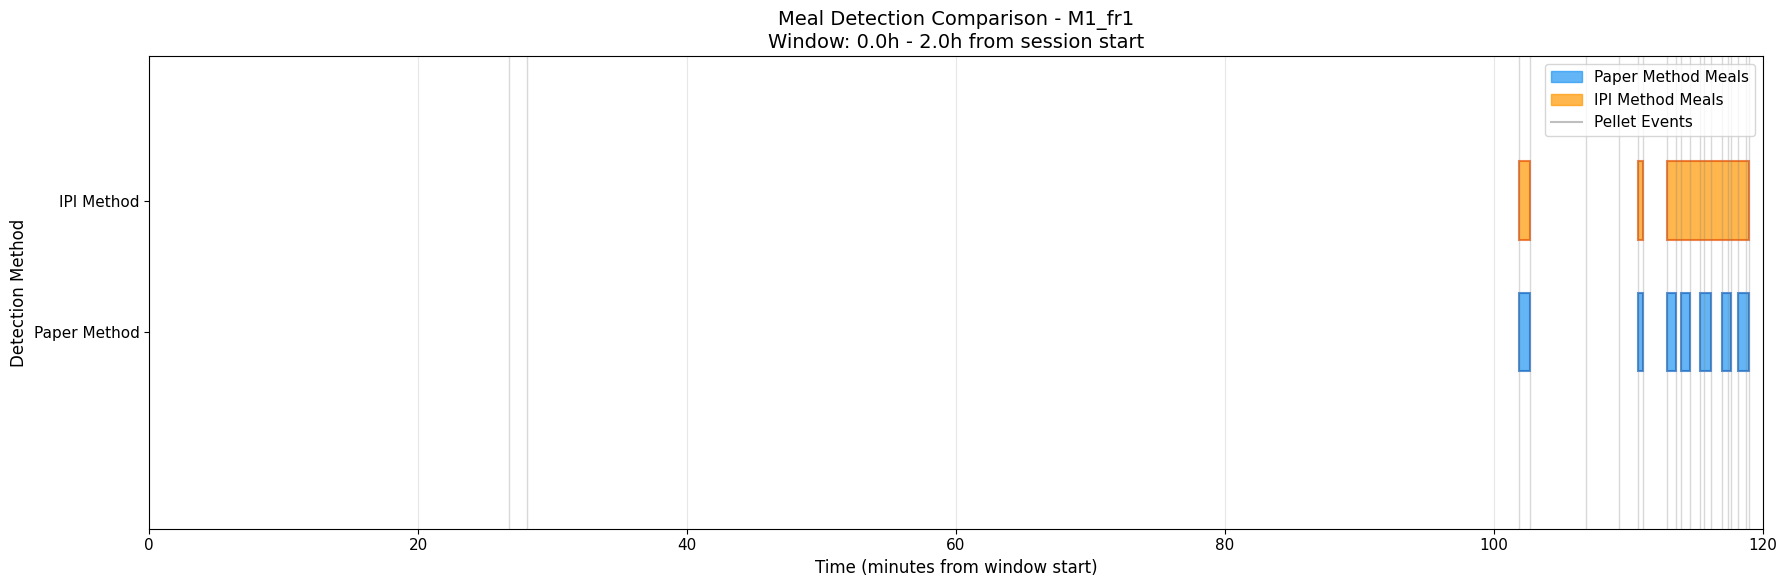

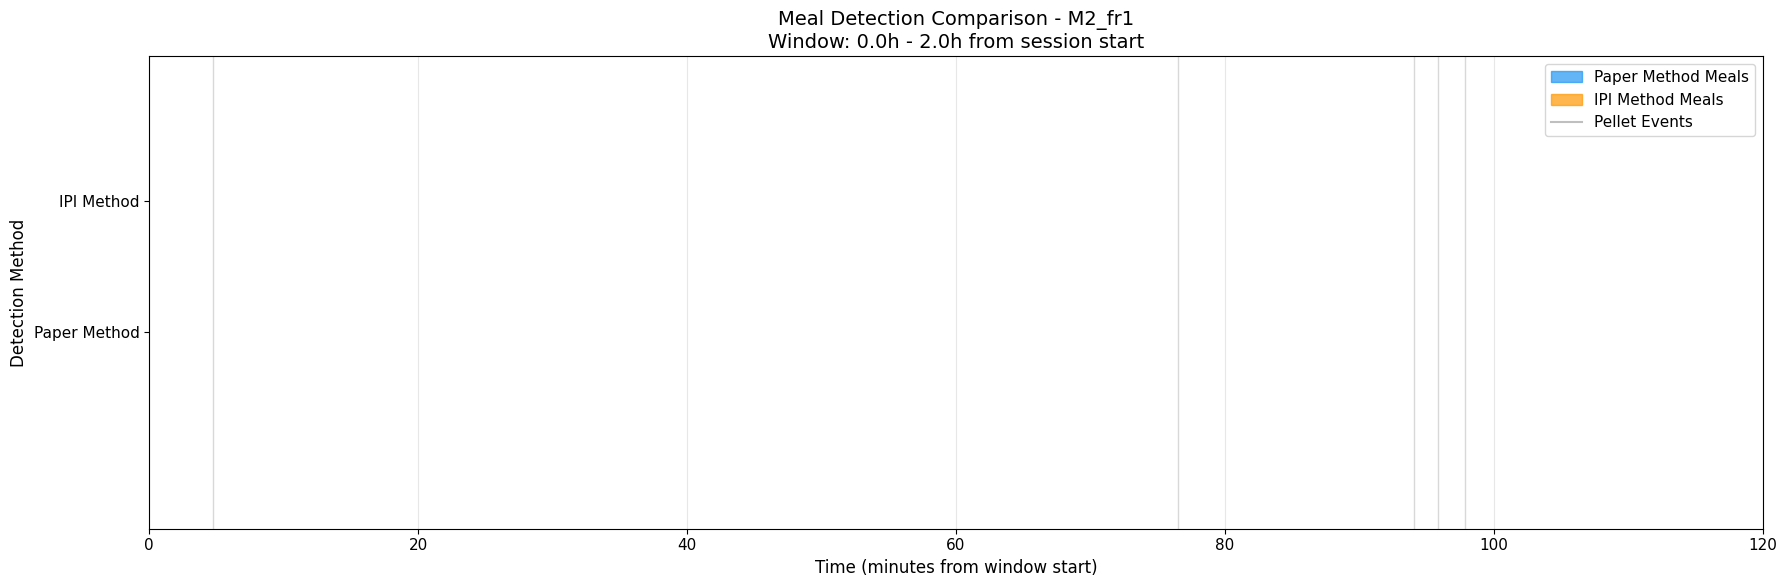

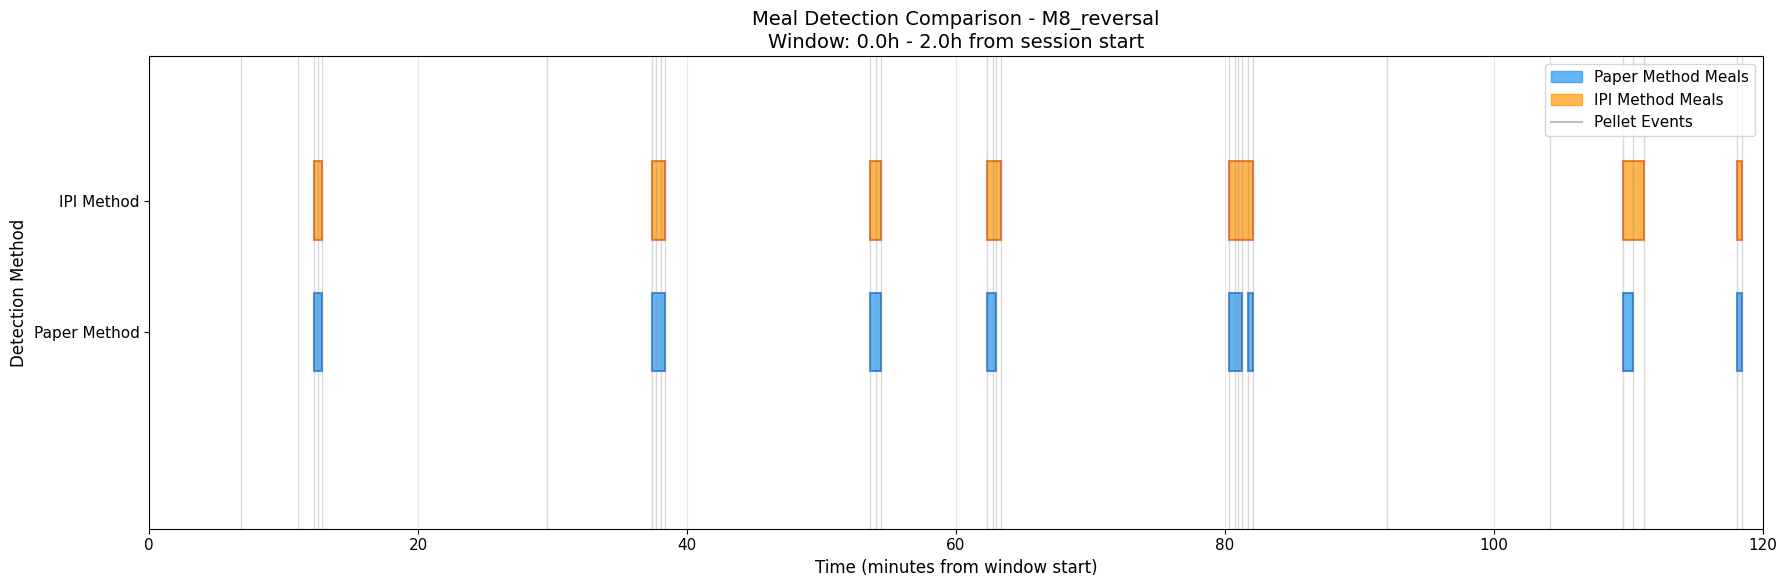

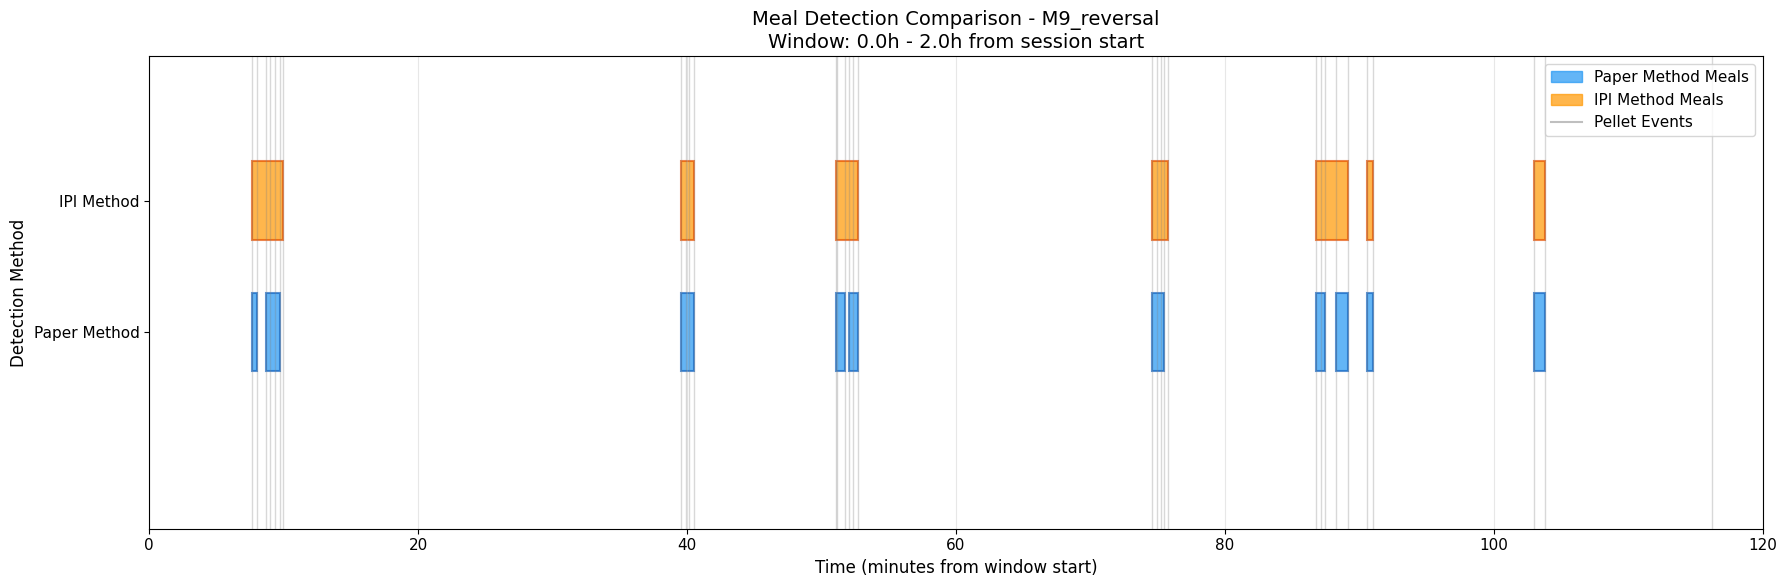

In [14]:
# Plot comparison for first few sessions
for session in sample_sessions[:4]:
    data = session.raw.copy()
    result = compare_meal_methods(data)
    
    # Plot first 2 hours
    fig = plot_meal_comparison_timeline(
        data,
        result['paper']['meals'],
        result['ipi']['meals'],
        session.key.session_id,
        time_window_hours=2.0,
        start_offset_hours=0.0
    )
    plt.show()
    plt.close()


## 5. Detailed Span Analysis: Finding Differences

This section identifies specific cases where the two methods produce notably different results.


In [12]:
def find_method_differences(paper_meals, ipi_meals, data):
    """
    Find cases where methods differ significantly.
    
    Returns list of time periods with notable differences.
    """
    differences = []
    
    # Find IPI-only meals (meals that IPI detects but paper doesn't)
    for ipi_start, ipi_end in ipi_meals:
        ipi_duration = (ipi_end - ipi_start).total_seconds()
        
        # Check if any paper meal overlaps significantly
        overlaps = False
        for paper_start, paper_end in paper_meals:
            overlap_start = max(ipi_start, paper_start)
            overlap_end = min(ipi_end, paper_end)
            if overlap_end > overlap_start:
                overlap = (overlap_end - overlap_start).total_seconds()
                if overlap > 0.5 * ipi_duration:  # >50% overlap
                    overlaps = True
                    break
        
        if not overlaps and ipi_duration > 60:  # IPI meal > 60s with no paper match
            differences.append({
                'type': 'ipi_extended',
                'start': ipi_start,
                'end': ipi_end,
                'duration': ipi_duration,
                'description': 'IPI detected extended meal that Paper split or missed'
            })
    
    return differences


In [ ]:
# Find notable differences across sessions
all_differences = []

for session in sample_sessions:
    data = session.raw.copy()
    result = compare_meal_methods(data)
    
    diffs = find_method_differences(
        result['paper']['meals'],
        result['ipi']['meals'],
        data
    )
    
    for d in diffs:
        d['session_id'] = session.key.session_id
        all_differences.append(d)

print(f"Found {len(all_differences)} notable differences where IPI detected extended meals")
if all_differences:
    diff_df = pd.DataFrame(all_differences)
    print(f"\nTop 10 longest IPI-extended meals:")
    display(diff_df.nlargest(10, 'duration')[['session_id', 'duration', 'start', 'end']])


## 6. Visualize Extended IPI Meals

Zoom into specific time windows where IPI detected notably longer meals.


In [ ]:
def plot_extended_meal_detail(
    session_id: str,
    session_store: dict,
    meal_start: pd.Timestamp,
    meal_end: pd.Timestamp,
    context_minutes: float = 5.0
):
    """
    Plot detailed view of a specific time window showing pellet-by-pellet behavior.
    """
    session = session_store[session_id]
    data = session.raw.copy()
    
    # Create window with context
    window_start = meal_start - pd.Timedelta(minutes=context_minutes)
    window_end = meal_end + pd.Timedelta(minutes=context_minutes)
    
    window_data = data[(data['Time'] >= window_start) & (data['Time'] <= window_end)]
    pellet_events = window_data[window_data['Event'] == 'Pellet'].copy()
    
    if pellet_events.empty:
        print(f"No pellets in window for {session_id}")
        return
    
    # Calculate interpellet intervals
    pellet_events = pellet_events.sort_values('Time').reset_index(drop=True)
    pellet_events['IPI'] = pellet_events['Time'].diff().dt.total_seconds()
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
    
    # Convert to minutes from window start
    pellet_events['minutes'] = (pellet_events['Time'] - window_start).dt.total_seconds() / 60
    
    # Top plot: Pellet timeline
    ax1.scatter(pellet_events['minutes'], [1]*len(pellet_events), 
               s=100, c='#4CAF50', marker='o', zorder=3, label='Pellets')
    
    # Shade meal period
    meal_start_min = (meal_start - window_start).total_seconds() / 60
    meal_end_min = (meal_end - window_start).total_seconds() / 60
    ax1.axvspan(meal_start_min, meal_end_min, alpha=0.3, color='#FF9800', label='IPI Meal Span')
    
    # Mark 60s threshold from first pellet
    first_pellet_min = pellet_events['minutes'].iloc[0]
    ax1.axvline(x=first_pellet_min + 1.0, color='#2196F3', linestyle='--', 
               linewidth=2, label='Paper 60s cutoff')
    
    ax1.set_ylabel('Pellet Events')
    ax1.set_ylim(0.5, 1.5)
    ax1.set_yticks([])
    ax1.legend(loc='upper right')
    ax1.set_title(f'Extended IPI Meal Analysis - {session_id}', fontsize=14)
    
    # Bottom plot: Interpellet intervals
    valid_ipi = pellet_events.dropna(subset=['IPI'])
    colors = ['#4CAF50' if ipi < 60 else '#F44336' for ipi in valid_ipi['IPI']]
    ax2.bar(valid_ipi['minutes'], valid_ipi['IPI'], width=0.3, color=colors, alpha=0.7)
    ax2.axhline(y=60, color='red', linestyle='--', linewidth=2, label='60s threshold')
    ax2.set_ylabel('Interpellet Interval (s)')
    ax2.set_xlabel('Time (minutes from window start)')
    ax2.legend(loc='upper right')
    ax2.set_ylim(0, max(100, valid_ipi['IPI'].max() * 1.1) if not valid_ipi.empty else 100)
    
    plt.tight_layout()
    return fig


In [ ]:
# Plot details for top extended meals
if all_differences:
    for diff in sorted(all_differences, key=lambda x: x['duration'], reverse=True)[:3]:
        print(f"\n{diff['session_id']}: Duration = {diff['duration']:.1f}s")
        try:
            fig = plot_extended_meal_detail(
                diff['session_id'],
                session_store,
                diff['start'],
                diff['end'],
                context_minutes=2.0
            )
            plt.show()
            plt.close()
        except Exception as e:
            print(f"Could not plot: {e}")


## 7. Duration Distribution Comparison


In [ ]:
# Collect all meal durations
paper_durations = []
ipi_durations = []

for session in sample_sessions:
    data = session.raw.copy()
    result = compare_meal_methods(data)
    
    for start, end in result['paper']['meals']:
        paper_durations.append((end - start).total_seconds())
    
    for start, end in result['ipi']['meals']:
        ipi_durations.append((end - start).total_seconds())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram comparison
ax1 = axes[0]
max_dur = max(max(paper_durations) if paper_durations else 0, max(ipi_durations) if ipi_durations else 0)
bins = np.arange(0, max_dur + 10, 5)
ax1.hist(paper_durations, bins=bins, alpha=0.6, color='#2196F3', label=f'Paper (n={len(paper_durations)})', edgecolor='black')
ax1.hist(ipi_durations, bins=bins, alpha=0.6, color='#FF9800', label=f'IPI (n={len(ipi_durations)})', edgecolor='black')
ax1.axvline(x=60, color='red', linestyle='--', linewidth=2, label='60s threshold')
ax1.set_xlabel('Meal Duration (seconds)')
ax1.set_ylabel('Frequency')
ax1.set_title('Meal Duration Distribution')
ax1.legend()
ax1.grid(alpha=0.3)

# Box plot comparison
ax2 = axes[1]
bp = ax2.boxplot([paper_durations, ipi_durations], labels=['Paper Method', 'IPI Method'],
                  patch_artist=True)
bp['boxes'][0].set_facecolor('#2196F3')
bp['boxes'][1].set_facecolor('#FF9800')
ax2.axhline(y=60, color='red', linestyle='--', linewidth=2, label='60s threshold')
ax2.set_ylabel('Meal Duration (seconds)')
ax2.set_title('Meal Duration Comparison')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 8. Pellets per Meal Comparison


In [ ]:
# Collect pellet counts per meal
paper_pellet_counts = []
ipi_pellet_counts = []

for session in sample_sessions:
    data = session.raw.copy()
    result = compare_meal_methods(data)
    
    for start, end in result['paper']['meals']:
        meal_data = data[(data['Time'] >= start) & (data['Time'] <= end)]
        count = len(meal_data[meal_data['Event'] == 'Pellet'])
        paper_pellet_counts.append(count)
    
    for start, end in result['ipi']['meals']:
        meal_data = data[(data['Time'] >= start) & (data['Time'] <= end)]
        count = len(meal_data[meal_data['Event'] == 'Pellet'])
        ipi_pellet_counts.append(count)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram
ax1 = axes[0]
max_pellets = max(max(paper_pellet_counts) if paper_pellet_counts else 2, 
                  max(ipi_pellet_counts) if ipi_pellet_counts else 2)
bins = np.arange(2, max_pellets + 2, 1)  # Start at 2 (minimum pellet threshold)
ax1.hist(paper_pellet_counts, bins=bins, alpha=0.6, color='#2196F3', 
        label=f'Paper (mean={np.mean(paper_pellet_counts):.1f})', edgecolor='black', align='left')
ax1.hist(ipi_pellet_counts, bins=bins, alpha=0.6, color='#FF9800',
        label=f'IPI (mean={np.mean(ipi_pellet_counts):.1f})', edgecolor='black', align='left')
ax1.set_xlabel('Pellets per Meal')
ax1.set_ylabel('Frequency')
ax1.set_title('Pellets per Meal Distribution')
ax1.legend()
ax1.grid(alpha=0.3)

# Cumulative distribution
ax2 = axes[1]
paper_sorted = np.sort(paper_pellet_counts)
ipi_sorted = np.sort(ipi_pellet_counts)
ax2.plot(paper_sorted, np.arange(1, len(paper_sorted)+1)/len(paper_sorted), 
        color='#2196F3', linewidth=2, label='Paper Method')
ax2.plot(ipi_sorted, np.arange(1, len(ipi_sorted)+1)/len(ipi_sorted),
        color='#FF9800', linewidth=2, label='IPI Method')
ax2.set_xlabel('Pellets per Meal')
ax2.set_ylabel('Cumulative Proportion')
ax2.set_title('Cumulative Distribution of Pellets per Meal')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 9. Shared vs Unique Meal Periods

Visualize overlap between methods using a timeline comparison.


In [ ]:
def plot_overlap_analysis(session, time_window_hours=4.0):
    """
    Show which time periods are detected by:
    - Both methods (overlap)
    - Paper only
    - IPI only
    """
    data = session.raw.copy()
    result = compare_meal_methods(data)
    
    session_start = data['Time'].iloc[0]
    window_end = session_start + pd.Timedelta(hours=time_window_hours)
    
    fig, ax = plt.subplots(figsize=(18, 4))
    
    def time_to_minutes(t):
        return (t - session_start).total_seconds() / 60
    
    # Plot Paper meals
    for start, end in result['paper']['meals']:
        if end < session_start or start > window_end:
            continue
        x_start = max(0, time_to_minutes(start))
        x_end = min(time_window_hours * 60, time_to_minutes(end))
        ax.barh(1, x_end - x_start, left=x_start, height=0.4, 
               color='#2196F3', alpha=0.7, edgecolor='#1565C0')
    
    # Plot IPI meals
    for start, end in result['ipi']['meals']:
        if end < session_start or start > window_end:
            continue
        x_start = max(0, time_to_minutes(start))
        x_end = min(time_window_hours * 60, time_to_minutes(end))
        ax.barh(0, x_end - x_start, left=x_start, height=0.4,
               color='#FF9800', alpha=0.7, edgecolor='#E65100')
    
    ax.set_xlim(0, time_window_hours * 60)
    ax.set_ylim(-0.5, 1.7)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['IPI Method', 'Paper Method'])
    ax.set_xlabel('Time (minutes from session start)')
    ax.set_title(f'Method Comparison Timeline - {session.key.session_id}')
    ax.grid(axis='x', alpha=0.3)
    
    # Stats
    paper_count = len([m for m in result['paper']['meals'] if m[0] < window_end])
    ipi_count = len([m for m in result['ipi']['meals'] if m[0] < window_end])
    ax.text(0.02, 0.95, f'Paper: {paper_count} meals | IPI: {ipi_count} meals',
           transform=ax.transAxes, fontsize=11, verticalalignment='top',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    return fig


In [ ]:
# Plot overlap analysis for selected sessions
for session in sample_sessions[:6]:
    fig = plot_overlap_analysis(session, time_window_hours=4.0)
    plt.show()
    plt.close()


## 10. Summary and Recommendations

### Key Findings

1. **Meal Count**: The Paper method tends to detect more (shorter) meals because it strictly limits each meal to 60s from the first pellet.

2. **Meal Duration**: IPI method can detect longer meals when animals eat continuously with short gaps between pellets.

3. **Use Cases**:
   - **Paper Method**: Better for standardized comparisons, consistent with published literature, ensures meals are bounded.
   - **IPI Method**: Better captures extended eating bouts, more naturalistic meal detection.

### When to Use Each Method

| Scenario | Recommended Method |
|----------|-------------------|
| Replicating paper analyses | Paper |
| Studying natural eating patterns | IPI |
| Comparing with published work | Paper |
| Detecting extended feeding bouts | IPI |


In [ ]:
# Final summary
print("=" * 70)
print("FINAL COMPARISON SUMMARY")
print("=" * 70)
print(f"\nSessions analyzed: {len(sample_sessions)}")
print(f"\nPaper Method:")
print(f"  - Total meals detected: {sum(comparison_df['paper_meal_count'])}")
print(f"  - Average meal duration: {np.mean(paper_durations):.1f}s")
print(f"  - Max meal duration: {max(paper_durations):.1f}s")
print(f"  - Average pellets/meal: {np.mean(paper_pellet_counts):.2f}")

print(f"\nIPI Method:")
print(f"  - Total meals detected: {sum(comparison_df['ipi_meal_count'])}")
print(f"  - Average meal duration: {np.mean(ipi_durations):.1f}s")
print(f"  - Max meal duration: {max(ipi_durations):.1f}s")
print(f"  - Average pellets/meal: {np.mean(ipi_pellet_counts):.2f}")

print(f"\nKey Differences:")
print(f"  - IPI detects {len(all_differences)} extended meals (>60s) not captured by Paper")
print(f"  - Paper detects {sum(comparison_df['paper_meal_count']) - sum(comparison_df['ipi_meal_count']):+d} more individual meals")
